# Plot mined data

Suggested Use:
- Supposed mined data are stored in an excel spreadsheet with identical formatting in each tab. This notebook reads selected columns of data as 'lon', 'lat' coordinates from each tab and selects the 'age' and 'SST mean' variables to visualize.
- Note that this notebook was created for mined SST data that has one specified column for 'age' in years BP and one specific 'SST mean' column in deg Celsius. Also defines marker type by 'proxy', which is the type of paleo temperature proxy used to infer SST from the given core analysis study. Needs to adapt code structure for parameters other than SST, e.g., IRD.

Versions:
- 2025.02.28 Created 'SST_Visual_old.ipynb' notebook, by Anna Chen
- 2025.04.10 Updated simple coordinate reading code, by AC
- 2025.12.04 Updated coordinate reading code with visualizations of SST and marker type when prompted with a specific year BP, by AC
- 2026.07.22 Copied first section of 'SST_Visual_old.ipynb' notebook to plot locations of mined data from excel notebook by AC, passed onto Avika

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # for plotting
import cartopy.crs as ccrs # for mapping coastlines
import cartopy.feature as cfeature # for mapping coastlines

## Set up

In [3]:
# Load the Excel file
# Remember your file should be stored in the same repository as your python notebook
excel_file = "SST_Data_Mining_2026-07-24.xlsx" # enter your excel file name here
xls = pd.ExcelFile(excel_file)
sheet_names = xls.sheet_names # I stored the core ID as the sheet name in the Excel file

# These are sheets that contain metadata or instructions rather than actual data, so we remove them from the list of sheets to process
sheets_to_remove = [
    "SUMMARY", 
    "TEMPLATE"
]

# Define proxy marker mapping
proxy_marker_map = {
    "Foram": "o",      # Circle
    "UK37": "^",       # Triangle
    "MgCa": "s",       # Square
    "Radiolaria": "D", # Diamond
    "Cocc": "P",       # Plus
    "Diatom": "X",      # Filled-X
    "TEX86": "v"       # Downward triangle
}

# Remove each sheet in sheets_to_remove if it exists in core_ID_list
for sheet in sheets_to_remove:
    if sheet in sheet_names:
        sheet_names.remove(sheet)

print("List of tabs with data in the Excel file:")
print(sheet_names)

List of tabs with data in the Excel file:
['ODP1148_TEX86', 'ODP1148_UK37', 'IODP-U1446', 'KNR191-CDH19', 'ODP1016C', 'ODP1014A', 'ODP999A', 'U939', 'SO136-111', 'MD02-2575', 'RC10-62', 'RC13-110', 'RC13-115', 'V19-29', 'VNTR1-8', 'Y69-106P', 'Y69-71P', 'Y71-3-2', 'Y71-9-101', 'Y71-6-12', 'ODP1239', 'NH22P', 'TR163-19', 'SK157-4', 'ODP 1094', 'KX97322-4', 'ODP 806B', 'RC09-166', 'MD85668', 'MD90963', 'MD85674', 'TY93-929-P', 'MD98-2152', 'ODP 982', 'Q200', 'R657', 'U938', 'MD99-2331_UK37', 'MD99-2331_Foram', 'ODP 1172A', 'ODP 1170A', 'ODP 1168A', 'MD01-2412', 'ODP 1125', 'ODP 847', 'GeoB10083', 'GeoB10163', 'GeoB10285', 'PS1778-5', 'ODP 1144', 'RS147-GC14', 'E45-29', 'E49-17', 'E49-18', 'E49-21', 'RC12-225', 'DSDP 593', 'ODP 882', 'VM19-193', 'ODP 871', 'MD97-2140', 'TSP-2PC', 'ODP 967', 'IODP U1485', 'IODP_U1482_UK37', 'IODP_U1482_TEX86']


## Simple version: read ('lon', 'lat') from each sheet and plot

     Longitude   Latitude       Proxy
0   116.566000  18.836000       TEX86
1   116.566000  18.836000        UK37
2    85.733000  19.083000        MgCa
3   -57.575980  33.690700        UK37
4  -122.283300  34.533330        UK37
5  -118.900000 -32.800000        UK37
6   -78.730000  12.750000        MgCa
7   179.300000 -44.320000        UK37
8   160.230000 -56.670000      Diatom
9   -87.118890  29.001670        MgCa
10 -101.430000   3.200000  Radiolaria
11  -96.080000   0.100000  Radiolaria
12 -104.500000  -1.380000  Radiolaria
13  -83.570000  -3.250000  Radiolaria
14 -110.480000   0.030000  Radiolaria
15  -86.550000   2.980000  Radiolaria
16  -86.480000   0.100000  Radiolaria
17  -85.250000   7.280000  Radiolaria
18 -106.950000  -6.630000  Radiolaria
19  -77.570000 -16.450000  Radiolaria
20  -82.080830  -0.672000        UK37
21 -106.520000  22.520000        UK37
22  -90.950000   2.250000        MgCa
23   78.000000   2.670000        MgCa
24    5.130333 -53.180350       TEX86
25  159.2443

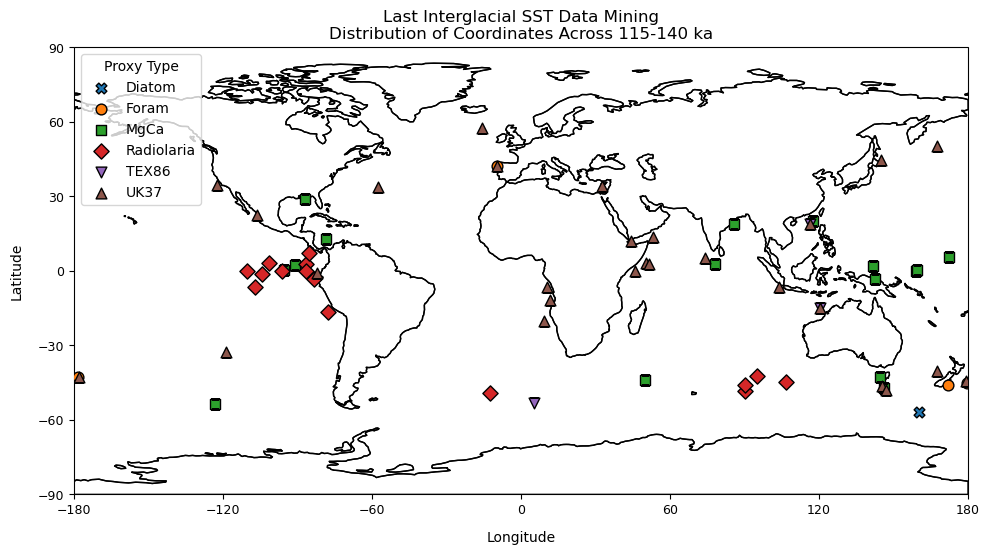

In [7]:
# Initialize a list to hold (longitude, latitude) tuples.
coords_proxy = []

# Loop through every sheet, but only process if not in sheets_to_remove.
for sheet in xls.sheet_names:
    if sheet in sheets_to_remove:
        continue  # Skip sheets in the remove list

    try:
        # Read only columns B, C, D from the first two rows.
        # Note: Excel row 2 corresponds to index 1 in pandas.
        df_sheet = pd.read_excel(excel_file, sheet_name=sheet, header=None, usecols="B:D", nrows=2)

        # Extract longitude from cell B2, latitude from cell C2, and proxy type from cell D2.
        lon = df_sheet.iloc[1, 0]
        lat = df_sheet.iloc[1, 1]
        proxy = df_sheet.iloc[1, 2]

        # Try converting the values to float; if conversion fails, skip this sheet.
        try:
            lon_val = float(lon)
            lat_val = float(lat)
            coords_proxy.append((lon_val, lat_val, proxy))
        except (ValueError, TypeError):
            continue  # Skip if conversion to float fails
    except Exception as e:
        print(f"Error processing sheet '{sheet}': {e}")

# Create a DataFrame from the list of tuples.
df_coords_proxy = pd.DataFrame(coords_proxy, columns=["Longitude", "Latitude", "Proxy"])

# Remove rows that contain any NaN values.
df_coords_proxy = df_coords_proxy.dropna().reset_index(drop=True)

# Optionally, display all rows in the DataFrame.
pd.set_option('display.max_rows', None)
print(df_coords_proxy)

# Plot the coordinates to visualize their distribution.
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='none', edgecolor='black')
ax.coastlines()

# Plot each proxy type separately so marker styles are applied correctly.
for proxy, group in df_coords_proxy.groupby("Proxy"):
    ax.scatter(
        group["Longitude"],
        group["Latitude"],
        transform=ccrs.PlateCarree(),
        marker=proxy_marker_map.get(proxy, 'o'),
        edgecolor='black', s=60,
        label=proxy,
        zorder=3
    )

ax.set_global()
ax.set_xticks(np.arange(-180, 181, 60), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(-90, 91, 30), crs=ccrs.PlateCarree())
ax.tick_params(axis="both", labelsize=9)
ax.set_xlabel("Longitude", labelpad=10)
ax.set_ylabel("Latitude", labelpad=10)
ax.set_title("Last Interglacial SST Data Mining\nDistribution of Coordinates Across 115-140 ka")
ax.legend(title="Proxy Type")
plt.tight_layout()
plt.show()


## Detailed version: read and plot coordinates, SST value, proxy type for a specified age (years BP)

/opt/miniconda3/envs/lig_sst/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/opt/miniconda3/envs/lig_sst/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/opt/miniconda3/envs/lig_sst/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/opt/miniconda3/envs/lig_sst/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/opt/miniconda3/envs/lig_sst/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/opt/miniconda3/envs/lig_sst/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supp

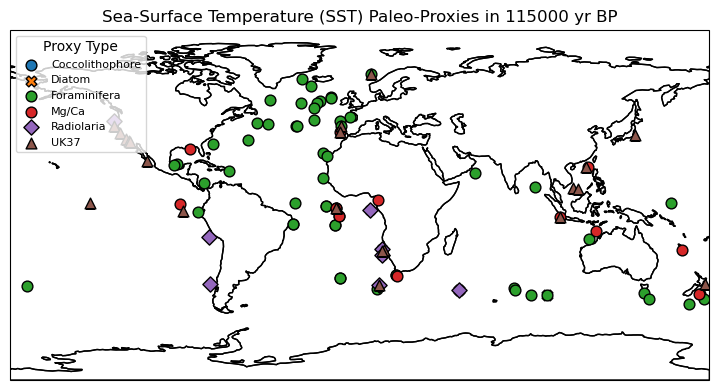

The data frame of records 115000 yr BP is:
              ID  Longitude  Latitude            Proxy        SST    SST+2sd  \
0       M23323-1       5.92     67.77             UK37   0.928067   7.676789   
1       M23323-1       5.92     67.77     Foraminifera   7.909945  12.667878   
2         V28-14     -29.57     64.78     Foraminifera   1.714295   8.807834   
3    EW9302-JPC8     -25.00     61.42     Foraminifera   5.128850  13.198928   
4        ODP 980     -14.70     55.48     Foraminifera   9.426281  15.202810   
..           ...        ...       ...              ...        ...        ...   
99      RC12-294     -10.10    -37.27     Foraminifera  10.779514  19.036086   
100     RC12-294     -10.10    -37.27  Coccolithophore  13.076077  19.606243   
101     ODP 1089       9.90    -40.93             UK37  18.677194  22.504049   
102     ODP 1089       9.90    -40.93       Radiolaria  11.865599  17.251886   
103     PS2489-2       8.97    -42.90     Foraminifera   3.443562   9.394030 

In [5]:
def extract_record_for_sheet(sheet, year_input):
    """
    For a given sheet name and year:
      - Reads columns B, C, D (Longitude, Latitude, Proxy) and extracts row 2 (first data row).
      - Reads columns Q and S (Age and SST Mean), finds the row where Age matches the given year,
        and extracts the SST Mean.
      - Returns a dictionary with keys: "Longitude", "Latitude", "Proxy", and "SST".
      - If no matching year is found, returns None.
    """
    try:
        # Read base info (columns B, C, D) from row 2 only.
        df_base = pd.read_excel(excel_file, sheet_name=sheet, usecols="A,B,C,D")
        df_base.columns = ['ID', 'Longitude', 'Latitude', 'Proxy']
        # Row 2 is the first data row (index 0)
        ID = df_base.iloc[0]['ID']
        lon = df_base.iloc[0]['Longitude']
        lat = df_base.iloc[0]['Latitude']
        proxy = df_base.iloc[0]['Proxy']
        if proxy == "MgCa":
            proxy = "Mg/Ca"
        if proxy == "Cocc":
            proxy = "Coccolithophore"
        if proxy == "Foram":
            proxy = "Foraminifera"
    except Exception as e:
        print(f"Error reading base info from sheet {sheet}: {e}")
        return None

    try:
        # Read age and SST info (columns Q and S) for all rows.
        df_sst = pd.read_excel(excel_file, sheet_name=sheet, usecols="R,T,S,U")
        df_sst.columns = ['Age', 'SST', 'SST-2sd', 'SST+2sd']
        # Find the row where Age matches the entered year.
        match = df_sst[df_sst['Age'] == year_input]
        if match.empty:
            print(f"Year {year_input} not found in sheet {sheet}.")
            return None
        # Extract the SST value from the first matching row.
        sst_val = match.iloc[0]['SST']
        sst_upper_val = match.iloc[0]['SST+2sd']
        sst_lower_val = match.iloc[0]['SST-2sd']
    except Exception as e:
        print(f"Error reading SST info from sheet {sheet}: {e}")
        return None

    return {"ID": ID, "Longitude": lon, "Latitude": lat, "Proxy": proxy,
            "SST": sst_val, "SST+2sd": sst_upper_val, "SST-2sd": sst_lower_val}

def build_gdf(year_input):
    """
    Loop through all sheets, extract records for the given year, and return a DataFrame.
    """
    records = []
    for sheet in sheet_names:
        rec = extract_record_for_sheet(sheet, year_input)
        if rec is not None:
            records.append(rec)
    if records:
        return pd.DataFrame(records)
    else:
        return pd.DataFrame()

def plot_proxy_data(gdf):
    """
    Plots the data grouped by proxy type onto a Cartopy world map.
    """
    # Create a Cartopy map
    fig = plt.figure(figsize=(8, 4))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='none', edgecolor='black')
    ax.coastlines()
    ax.set_global()

    # Group the data by proxy type and plot each group.
    for proxy, group in gdf.groupby("Proxy"):
        ax.scatter(
            group['Longitude'], group['Latitude'],
            transform=ccrs.PlateCarree(),
            marker=proxy_marker_map.get(proxy, "o"),
            edgecolor="black", s=60,
            label=proxy,
            zorder=3
        )

    # Add legend for proxy types and coordinate labels.
    ax.legend(title="Proxy Type", loc='upper left', prop={'size': 8})
    ax.set_xlabel("Longitude", labelpad=10)
    ax.set_ylabel("Latitude", labelpad=10)
    ax.set_title(f"Sea-Surface Temperature (SST) Paleo-Proxies in {year_input} yr BP")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    try:
        year_input = int(input("Enter a specific year before present (e.g., 115000): "))
    except ValueError:
        print("Invalid year input.")
        exit()

    # Build the DataFrame of records.
    gdf = build_gdf(year_input)
    if gdf.empty:
        print("No records found for the given year.")
    else:
        # Plot the data grouped by proxy type.
        plot_proxy_data(gdf)

    # Print the DataFrame of records.
    print(f"The data frame of records {year_input} yr BP is:")
    print(gdf)